# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv("data/AviationData_Cleaned.csv", low_memory=False)
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Total.Passengers,Frac.Fatal.Serious,Destroyed,Plane.Type
0,20001214X42095,Accident,SEA83LA036,1983-01-01,"NEWPORT, OR",United States,ONP,NEWPORT MUNICIPAL,Non-Fatal,Substantial,...,1.0,3.0,Vmc,Approach,Probable Cause,NaN,4.0,0.0,False,Cessna 182P
1,20001214X42067,Accident,MKC83LA056,1983-01-01,"WOODBINE, IA",United States,3YR,MUNICIPAL,Non-Fatal,Substantial,...,0.0,2.0,Vmc,Landing,Probable Cause,NaN,2.0,0.0,False,Cessna 182Rg
2,20001214X42063,Accident,MKC83LA050,1983-01-01,"MARYVILLE, MO",United States,78Y,RANKIN,Non-Fatal,Substantial,...,0.0,1.0,Vmc,Takeoff,Probable Cause,NaN,1.0,0.0,False,Cessna 182P
3,20001214X42018,Accident,LAX83FUG11,1983-01-01,"UPLAND, CA",United States,CCB,CABLE,Non-Fatal,Substantial,...,2.0,0.0,Vmc,Approach,Probable Cause,NaN,2.0,0.0,False,Piper Pa-28R-200
4,20001214X41951,Accident,CHI83LA074,1983-01-01,"SPRINGBROOK, WI",United States,NaN,SPRINGBROOK,Non-Fatal,Substantial,...,0.0,2.0,Vmc,Landing,Probable Cause,NaN,2.0,0.0,False,Cessna 140


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
# small vs large aircraft based on passenger threshold
small_planes = df[df['Total.Passengers'] <= 20]
large_planes = df[df['Total.Passengers'] > 20]

# counts
print("Small planes:", small_planes.shape[0])
print("Large planes:", large_planes.shape[0])

Small planes: 67995
Large planes: 2544


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

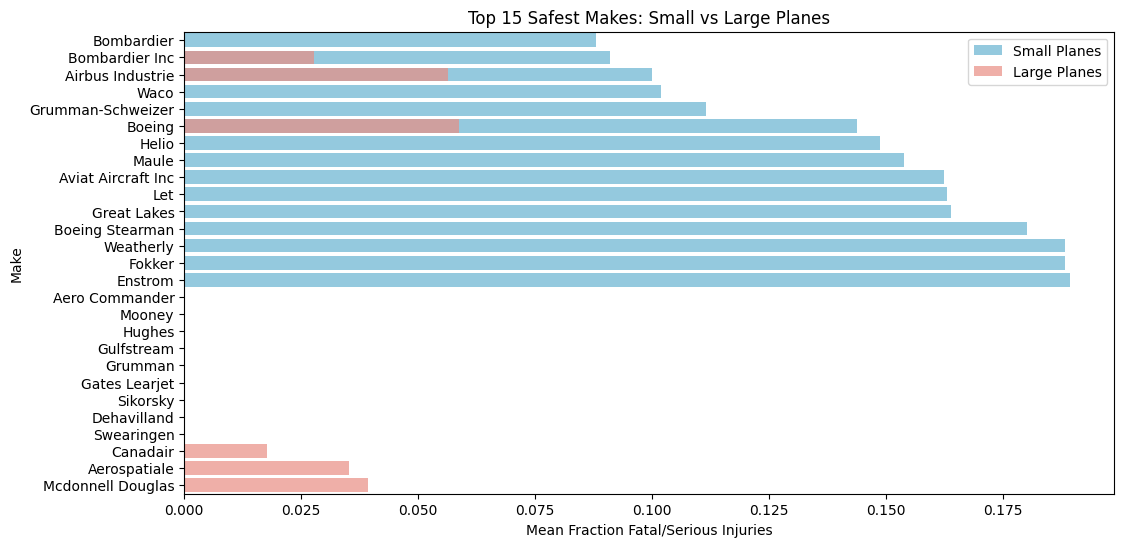

In [4]:
# Small planes: 15 safest makes
top15_small_makes = (small_planes.groupby('Make')
                     ['Frac.Fatal.Serious']
                     .mean()
                     .sort_values()
                     .head(15))

# Large planes: 15 safest makes
top15_large_makes = (large_planes.groupby('Make')
                     ['Frac.Fatal.Serious']
                     .mean()
                     .sort_values()
                     .head(15))

# plot
plt.figure(figsize=(12,6))
sns.barplot(x=top15_small_makes.values, y=top15_small_makes.index, color='skyblue', label='Small Planes')
sns.barplot(x=top15_large_makes.values, y=top15_large_makes.index, color='salmon', label='Large Planes', alpha=0.7)
plt.xlabel('Mean Fraction Fatal/Serious Injuries')
plt.title('Top 15 Safest Makes: Small vs Large Planes')
plt.legend()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

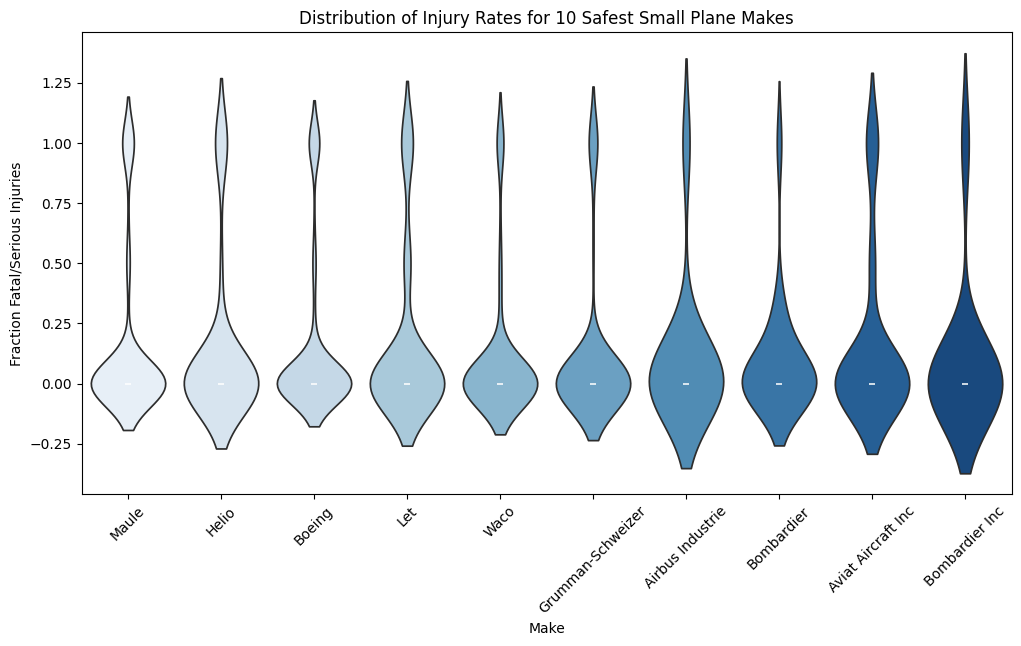

In [5]:
# Small planes: 10 safest makes
top10_small_makes = (small_planes.groupby('Make')['Frac.Fatal.Serious']
                     .mean()
                     .sort_values()
                     .head(10)
                     .index)

# filter
small_top10_df = small_planes[small_planes['Make'].isin(top10_small_makes)]

# plot
plt.figure(figsize=(12,6))
sns.violinplot(x='Make', y='Frac.Fatal.Serious', data=small_top10_df, palette='Blues', hue='Make', legend=False)
plt.xticks(rotation=45)
plt.ylabel('Fraction Fatal/Serious Injuries')
plt.title('Distribution of Injury Rates for 10 Safest Small Plane Makes')
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

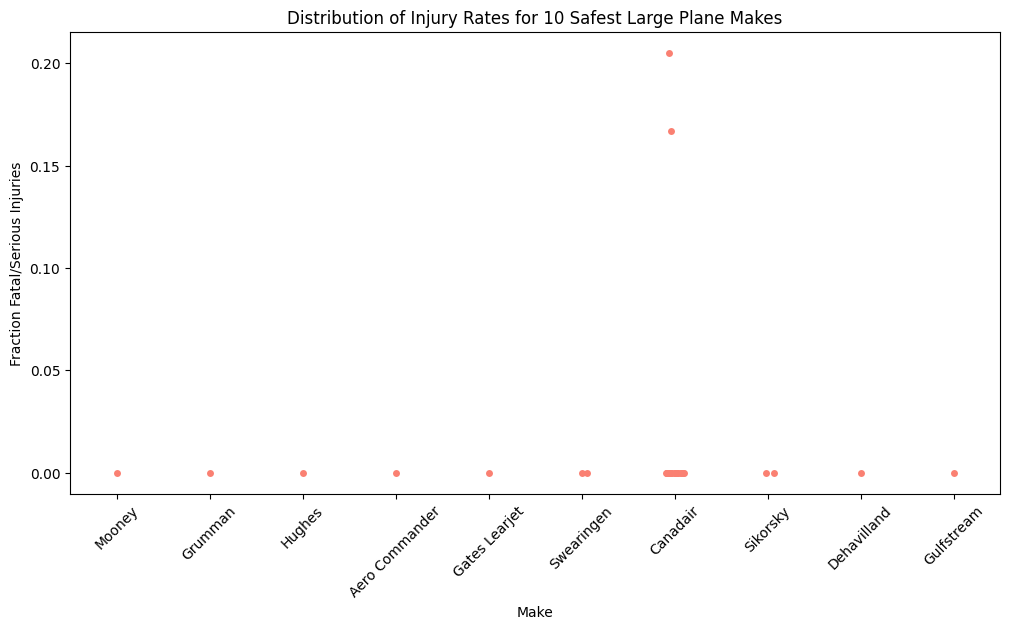

In [6]:
# Large planes: 10 safest makes
top10_large_makes = (large_planes.groupby('Make')['Frac.Fatal.Serious']
                     .mean()
                     .sort_values()
                     .head(10)
                     .index)

# filter
large_top10_df = large_planes[large_planes['Make'].isin(top10_large_makes)]

# plot
plt.figure(figsize=(12,6))
sns.stripplot(x='Make', y='Frac.Fatal.Serious', data=large_top10_df, color='salmon', jitter=True)
plt.xticks(rotation=45)
plt.ylabel('Fraction Fatal/Serious Injuries')
plt.title('Distribution of Injury Rates for 10 Safest Large Plane Makes')
plt.show()


**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [7]:
# Small planes: 15 makes with lowest mean destruction rate
top15_small_destroyed = (small_planes.groupby('Make')['Destroyed']
                         .mean()
                         .sort_values()
                         .head(15))

# Large planes: 15 makes with lowest mean destruction rate
top15_large_destroyed = (large_planes.groupby('Make')['Destroyed']
                         .mean()
                         .sort_values()
                         .head(15))

print("Top 15 Small Plane Makes (Lowest Destruction Rate):\n", top15_small_destroyed)
print("\nTop 15 Large Plane Makes (Lowest Destruction Rate):\n", top15_large_destroyed)

Top 15 Small Plane Makes (Lowest Destruction Rate):
 Make
Grumman Acft Eng Cor-Schweizer    0.017241
Airbus                            0.025316
Bombardier                        0.026316
American Champion Aircraft        0.037037
Aviat Aircraft Inc                0.038961
Dehavilland                       0.040000
Bombardier Inc                    0.043478
Diamond Aircraft Ind Inc          0.054054
Flight Design Gmbh                0.060000
Robinson Helicopter               0.060870
Boeing                            0.061081
Raven                             0.063291
Balloon Works                     0.064748
Airbus Industrie                  0.080000
Let                               0.081481
Name: Destroyed, dtype: float64

Top 15 Large Plane Makes (Lowest Destruction Rate):
 Make
Aero Commander       0.000000
Mooney               0.000000
Hughes               0.000000
Gulfstream           0.000000
Grumman              0.000000
Gates Learjet        0.000000
Sikorsky             0.000

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

##### Findings
- Small Planes: Safest makes hav low mean fatal/seriou injury fractions around < 0.10 and low destruction rates, mostly < ~0.06. The violin plot shows distributions concentrated near 0, with occasional outliers which indicate accidents being survivable.
- Large Planes: Several makes (Gulfstream, Mooney, Grumman, Aero Commander) show close to 0 destruction rates and low injury fractions. Strip plot shows most observations at 0, with very few high-injury cases with some outlier exceptions with the Canadair.

##### Recommandations
- Small Planes: Prioritize makes that appear low in injury and destruction lists, i.e. Grumman-Schweizer, Bombardier/Bombardier Inc, Airbus Industrie, and Aviat Aircraft Inc.
- Large Planes: Strong candidates include Gulfstream, Grumman, Aero Commander, Gates Learjet, and Bombardier Inc, given consistently low destruction and injury rates.

##### Comments
- Injury fractions are skewed right; most accidents result in zero serious/fatal injuries
- Destruction rates are generally low across top makes, especially for large crafts
- Makes the perform well across both metrics provide strongest evidence-based recommendations.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.